# Modelo de Cantidad a Reponer — Inventario ALDIMI
**Machine Learning 1ACC0057 · UPC · Grupo 2 · Hito 4**

Este notebook entrena un modelo de **regresión** que predice cuánto se va a
consumir de cada producto en los próximos **7 y 14 días**, y lo convierte en una
**cantidad concreta a pedir** (lista de compras) — a diferencia de
`aldimi_analisis_modelado.ipynb`, que clasifica "riesgo de quiebre" (sí/no).

**Por qué un segundo modelo:**
1. El enunciado pide explícitamente *"Modelos de Regresión o Series Temporales"*
   y *"modelado de consumo basado en la ocupación proyectada (50 a 100 familias)"*
   para el frente de inventario. El modelo de clasificación no cubre ese punto
   literalmente.
2. En el chat del equipo (4 jul), Leonel e Iván coincidieron en que "riesgo" sin
   ventana temporal no tenía mucho sentido de negocio, y que predecir cantidad
   es más medible y permite generar una lista de compras.

Este notebook **no reemplaza** el modelo de clasificación existente — ambos
pueden convivir en el dashboard: uno prioriza *qué* atender primero, el otro dice
*cuánto* pedir.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

RUTA = '../data/processed'
df_sem = pd.read_csv(f'{RUTA}/aldimi_dataset_semanal.csv')
real = df_sem[df_sem['es_producto'] == True].copy()
print(f"Filas totales: {len(df_sem)} · Solo productos reales: {len(real)} "
      f"({real['codigo_articulo'].nunique()} productos, "
      f"{real['semana_del_año'].nunique()} semanas)")
real.head(3)

Filas totales: 5460 · Solo productos reales: 3068 (59 productos, 52 semanas)


,codigo_articulo,categoria,semana_del_año,ocupacion_albergue,stock_inicio_semana,ingresos_semana,salidas_semana,stock_fin_semana,rolling_avg_salidas_3sem,alerta_7_dias,alerta_14_dias,nombre_producto,presentacion,unidad_medida,categoria_general,es_producto
0,0002ME,Menestras,1,54,0.21,0.00,0.05,0.16,0.05,0,0,Arverja partida 1 kg,1 kg,kg,Menestras,True
1,0002ME,Menestras,2,58,0.16,0.18,0.05,0.29,0.05,0,0,Arverja partida 1 kg,1 kg,kg,Menestras,True
2,0002ME,Menestras,3,60,0.29,0.00,0.05,0.24,0.05,0,0,Arverja partida 1 kg,1 kg,kg,Menestras,True


## 1. Business Understanding

**Variable objetivo:** cantidad de unidades que se van a consumir en los
próximos 7 y 14 días para cada producto (`target_7d`, `target_14d`), a partir de
`salidas_semana` — la misma columna que ya usa el modelo de clasificación.

**Criterio de éxito técnico:** que el error (MAE) sea menor que el de un
*baseline* ingenuo (asumir que el consumo futuro es igual al promedio móvil de
las últimas 3 semanas, que ya se usa como feature en el modelo de clasificación).
Si no le gana claramente al baseline, lo decimos con transparencia — es
información útil igual (ver sección 5).

**De la predicción a la acción:** con `stock_fin_semana` (lo que ya hay) y la
cantidad predicha, se calcula cuánto pedir: `cantidad_a_pedir = max(0,
predicho − stock_actual)`, redondeado según la unidad de medida del producto
(no tiene sentido pedir "0.7 latas" — sección 8).

## 2. Data Preparation — construcción del target futuro

Para cada producto, ordenado por semana, el target de una fila en la semana
*t* es el consumo real de las semanas *t+1* (7 días) y *t+1 + t+2* (14 días).
Solo se usan como *features* variables conocidas **en la semana t o antes**
(stock, ocupación, promedio móvil, categoría) — así se evita fuga de datos
desde el futuro.

In [2]:
real = real.sort_values(['codigo_articulo', 'semana_del_año']).reset_index(drop=True)
g = real.groupby('codigo_articulo')['salidas_semana']

real['target_7d'] = g.shift(-1)
s1, s2 = g.shift(-1), g.shift(-2)
real['target_14d'] = (s1.fillna(0) + s2.fillna(0)).where(s2.notna())

print('Filas con target_7d válido: ', real['target_7d'].notna().sum())
print('Filas con target_14d válido:', real['target_14d'].notna().sum())
real[['codigo_articulo', 'semana_del_año', 'salidas_semana',
      'rolling_avg_salidas_3sem', 'target_7d', 'target_14d']].head(6)

Filas con target_7d válido:  3009
Filas con target_14d válido: 2950


,codigo_articulo,semana_del_año,salidas_semana,rolling_avg_salidas_3sem,target_7d,target_14d
0,0002ME,1,0.05,0.0500,0.05,0.10
1,0002ME,2,0.05,0.0500,0.05,0.11
2,0002ME,3,0.05,0.0500,0.06,0.11
3,0002ME,4,0.06,0.0533,0.05,0.10
4,0002ME,5,0.05,0.0533,0.05,0.10
5,0002ME,6,0.05,0.0533,0.05,0.09


## 3. Split temporal (train / test)

Igual que en una serie de tiempo real: se entrena con las primeras semanas y se
evalúa contra semanas que el modelo **nunca vio**, en vez de un split aleatorio
(que sería optimista y no simularía un despliegue real, donde solo se conoce el
pasado).

In [3]:
FEATS_NUM = ['ocupacion_albergue', 'stock_inicio_semana', 'stock_fin_semana',
             'rolling_avg_salidas_3sem', 'semana_del_año']
FEATS_CAT = ['categoria_general']
SEMANA_CORTE = 40

def preparar(target_col):
    d = real.dropna(subset=[target_col]).copy()
    train = d[d['semana_del_año'] <= SEMANA_CORTE]
    test  = d[d['semana_del_año'] >  SEMANA_CORTE]
    return train, test

train7, test7   = preparar('target_7d')
train14, test14 = preparar('target_14d')
print(f"7 días : train={train7.shape}  test={test7.shape}")
print(f"14 días: train={train14.shape} test={test14.shape}")

7 días : train=(2360, 18)  test=(649, 18)
14 días: train=(2360, 18) test=(590, 18)


## 4. Modeling — comparativa de algoritmos

Se comparan 4 enfoques para cada horizonte:
1. **Naive (persistencia):** predecir = promedio móvil de las últimas 3 semanas
   (lo que implícitamente ya "asume" el sistema hoy).
2. **Regresión Lineal** — baseline pedido en el Hito 2.
3. **Random Forest Regressor** — con `RandomizedSearchCV` + `TimeSeriesSplit`
   (igual que el resto del proyecto).
4. **XGBoost Regressor** — mismo esquema de tuning.

In [4]:
pre = ColumnTransformer([
    ('num', StandardScaler(), FEATS_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore'), FEATS_CAT),
])

PARAM_RF = {'reg__n_estimators': [100, 150, 200],
            'reg__max_depth': [4, 6, 8],
            'reg__min_samples_leaf': [1, 2, 4]}
PARAM_XGB = {'reg__n_estimators': [100, 150, 200],
             'reg__max_depth': [3, 4, 5],
             'reg__learning_rate': [0.05, 0.1],
             'reg__subsample': [0.8, 1.0]}


def tunear(estimador, params, X_train, y_train, n_iter=6):
    tscv = TimeSeriesSplit(n_splits=3)
    search = RandomizedSearchCV(estimador, params, n_iter=n_iter, cv=tscv,
                                 scoring='neg_mean_absolute_error',
                                 random_state=RANDOM_STATE, n_jobs=1)
    search.fit(X_train, y_train)
    return search.best_estimator_, search.best_params_


def metricas(y_true, y_pred):
    return {'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
            'R2': r2_score(y_true, y_pred)}


resultados = {}
modelos_entrenados = {}

for horizonte, (train, test, target_col) in {
        '7 días':  (train7, test7, 'target_7d'),
        '14 días': (train14, test14, 'target_14d')}.items():

    Xtr, ytr = train[FEATS_NUM + FEATS_CAT], train[target_col]
    Xte, yte = test[FEATS_NUM + FEATS_CAT], test[target_col]

    filas = {}

    # 1) Naive: predicho = rolling_avg_salidas_3sem (x2 para 14 días)
    factor = 1 if horizonte == '7 días' else 2
    pred_naive = Xte['rolling_avg_salidas_3sem'] * factor
    filas['Naive (persistencia)'] = metricas(yte, pred_naive)

    # 2) Regresión Lineal
    lr = Pipeline([('prep', pre), ('reg', LinearRegression())]).fit(Xtr, ytr)
    filas['Regresión Lineal'] = metricas(yte, lr.predict(Xte))

    # 3) Random Forest (tuneado)
    rf_base = Pipeline([('prep', pre),
                        ('reg', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))])
    rf, rf_params = tunear(rf_base, PARAM_RF, Xtr, ytr)
    filas['Random Forest'] = metricas(yte, rf.predict(Xte))

    # 4) XGBoost (tuneado)
    xgb_base = Pipeline([('prep', pre),
                         ('reg', XGBRegressor(random_state=RANDOM_STATE))])
    xgb, xgb_params = tunear(xgb_base, PARAM_XGB, Xtr, ytr)
    filas['XGBoost'] = metricas(yte, xgb.predict(Xte))

    resultados[horizonte] = pd.DataFrame(filas).T
    modelos_entrenados[horizonte] = {'lr': lr, 'rf': rf, 'xgb': xgb,
                                      'rf_params': rf_params, 'xgb_params': xgb_params,
                                      'Xte': Xte, 'yte': yte}
    print(f"\n=== {horizonte} ===")
    print(resultados[horizonte].round(4))
    print(f"Mejores hiperparámetros RF:  {rf_params}")
    print(f"Mejores hiperparámetros XGB: {xgb_params}")


=== 7 días ===
                         MAE    RMSE      R2
Naive (persistencia)  0.1025  0.5579  0.9661
Regresión Lineal      0.1204  0.6001  0.9608
Random Forest         0.1299  0.5712  0.9645
XGBoost               0.1375  0.8840  0.9149
Mejores hiperparámetros RF:  {'reg__n_estimators': 200, 'reg__min_samples_leaf': 4, 'reg__max_depth': 4}
Mejores hiperparámetros XGB: {'reg__subsample': 1.0, 'reg__n_estimators': 100, 'reg__max_depth': 5, 'reg__learning_rate': 0.05}



=== 14 días ===
                         MAE    RMSE      R2
Naive (persistencia)  0.1670  0.9981  0.9724
Regresión Lineal      0.2038  1.0720  0.9682
Random Forest         0.1814  0.9494  0.9750
XGBoost               0.1922  1.0357  0.9703
Mejores hiperparámetros RF:  {'reg__n_estimators': 100, 'reg__min_samples_leaf': 2, 'reg__max_depth': 8}
Mejores hiperparámetros XGB: {'reg__subsample': 1.0, 'reg__n_estimators': 200, 'reg__max_depth': 5, 'reg__learning_rate': 0.1}


## 5. Evaluación honesta: ¿le ganamos al baseline ingenuo?

En un almacén con consumo semanal muy estable, un baseline "ingenuo" (asumir que
el futuro se parece al promedio reciente) puede ser sorprendentemente
competitivo. Vale más decir esto con transparencia que maquillarlo — es
exactamente el tipo de "juicio de ingeniería" que pide la rúbrica del curso.

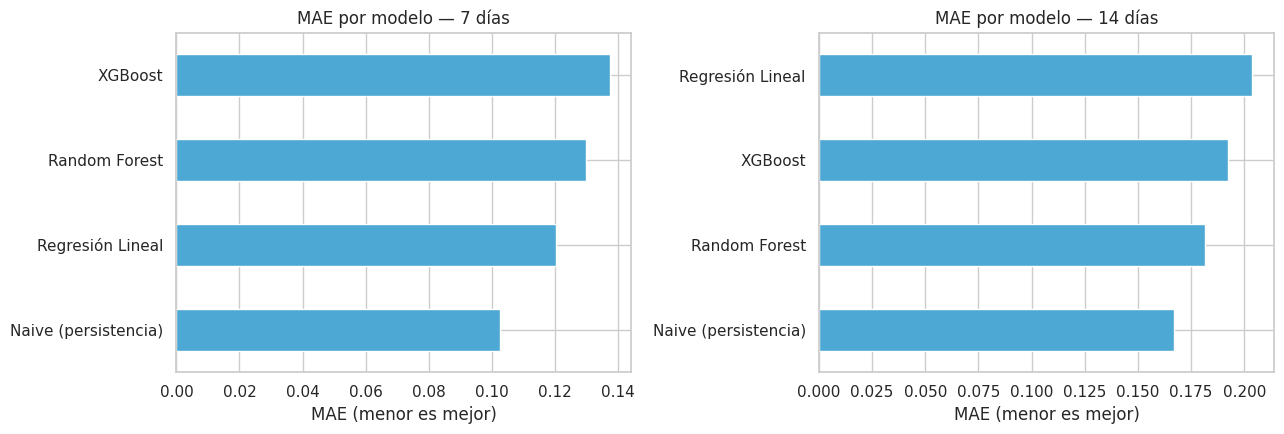

7 días: mejor MAE = Naive (persistencia) (el baseline naive gana o empata)
14 días: mejor MAE = Naive (persistencia) (el baseline naive gana o empata)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (horizonte, tabla) in zip(axes, resultados.items()):
    tabla['MAE'].sort_values().plot.barh(ax=ax, color='#4da9d4')
    ax.set_title(f'MAE por modelo — {horizonte}')
    ax.set_xlabel('MAE (menor es mejor)')
plt.tight_layout(); plt.show()

for horizonte, tabla in resultados.items():
    gana_naive = tabla['MAE'].idxmin() == 'Naive (persistencia)'
    print(f"{horizonte}: mejor MAE = {tabla['MAE'].idxmin()} "
          f"({'el baseline naive gana o empata' if gana_naive else 'un modelo entrenado le gana al naive'})")

In [6]:
mejor_modelo = {}
for horizonte, tabla in resultados.items():
    # Se elige el mejor MODELO ENTRENADO (no el naive: no es un artefacto desplegable
    # con predict(X) sobre escenarios hipotéticos de ocupación/categoría).
    candidatos = tabla.drop(index='Naive (persistencia)')
    nombre = candidatos['MAE'].idxmin()
    mejor_modelo[horizonte] = nombre
    print(f"{horizonte}: modelo seleccionado para producción → {nombre} "
          f"(MAE={candidatos.loc[nombre, 'MAE']:.4f}, R²={candidatos.loc[nombre, 'R2']:.4f})")

7 días: modelo seleccionado para producción → Regresión Lineal (MAE=0.1204, R²=0.9608)
14 días: modelo seleccionado para producción → Random Forest (MAE=0.1814, R²=0.9750)


## 6. Importancia de variables (mejor modelo, 14 días)

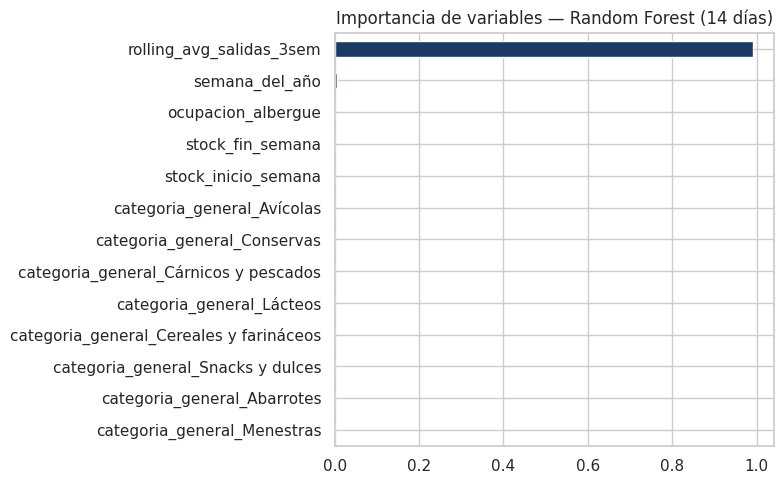

In [7]:
info14 = modelos_entrenados['14 días']
nombre_modelo_14 = mejor_modelo['14 días']
clave = {'Regresión Lineal': 'lr', 'Random Forest': 'rf', 'XGBoost': 'xgb'}[nombre_modelo_14]
pipe14 = info14[clave]

reg = pipe14.named_steps['reg']
nombres_feat = (FEATS_NUM +
                list(pipe14.named_steps['prep']
                     .named_transformers_['cat'].get_feature_names_out(FEATS_CAT)))

if hasattr(reg, 'feature_importances_'):
    imp = pd.Series(reg.feature_importances_, index=nombres_feat).sort_values()
    fig, ax = plt.subplots(figsize=(8, 5))
    imp.plot.barh(ax=ax, color='#1b3b64')
    ax.set_title(f'Importancia de variables — {nombre_modelo_14} (14 días)')
    plt.tight_layout(); plt.show()
else:
    coefs = pd.Series(reg.coef_, index=nombres_feat).sort_values()
    print(coefs)

## 7. Límite importante: rango de ocupación observado vs. reto de 100 familias

El enunciado pide *"modelado de consumo basado en la ocupación proyectada (50 a
100 familias)"*. Antes de prometer eso, hay que revisar si el modelo realmente
aprendió una relación confiable con la ocupación, o si el histórico simplemente
no cubre ese rango.

In [8]:
print("Rango de ocupación observado en el histórico:")
print(real['ocupacion_albergue'].describe()[['min', 'max', 'mean', 'std']])

Rango de ocupación observado en el histórico:
min     40.000000
max     60.000000
mean    50.123207
std      6.010626
Name: ocupacion_albergue, dtype: float64


In [9]:
# Sensibilidad del modelo elegido a cambios de ocupación, con todo lo demás fijo
muestra = test14.groupby('codigo_articulo').first().reset_index().head(15).copy()
for occ in [50, 60, 75, 100]:
    m = muestra.copy()
    m['ocupacion_albergue'] = occ
    pred = pipe14.predict(m[FEATS_NUM + FEATS_CAT])
    print(f"ocupación simulada = {occ:3d} familias  ->  consumo 14d promedio predicho: {pred.mean():.3f}")

print()
print("Si el promedio predicho arriba casi no cambia entre 50 y 100, el modelo "
      "NO está capturando una relación fuerte con la ocupación (probable, dado que "
      "el histórico solo cubre 40–60). Para 100 familias no hay que confiar en la "
      "extrapolación del árbol — mejor usar la regla de negocio transparente de la "
      "sección 8, no el modelo de caja negra fuera de su rango de entrenamiento.")

ocupación simulada =  50 familias  ->  consumo 14d promedio predicho: 0.225
ocupación simulada =  60 familias  ->  consumo 14d promedio predicho: 0.219
ocupación simulada =  75 familias  ->  consumo 14d promedio predicho: 0.219
ocupación simulada = 100 familias  ->  consumo 14d promedio predicho: 0.219

Si el promedio predicho arriba casi no cambia entre 50 y 100, el modelo NO está capturando una relación fuerte con la ocupación (probable, dado que el histórico solo cubre 40–60). Para 100 familias no hay que confiar en la extrapolación del árbol — mejor usar la regla de negocio transparente de la sección 8, no el modelo de caja negra fuera de su rango de entrenamiento.


## 8. Regla de negocio complementaria: escalamiento per-cápita

Para proyectar más allá de lo que el histórico permite validar con ML, se usa
una regla simple y auditable (no una caja negra): consumo per-cápita histórico
por categoría × ocupación proyectada. Esto es lo que se debería usar para
simular explícitamente el escenario "100 familias" del enunciado, dejando el
modelo de ML para el horizonte de 7/14 días dentro del rango ya validado.

In [10]:
percapita = (real.assign(consumo_percapita=real['salidas_semana'] / real['ocupacion_albergue'])
                  .groupby('categoria_general')['consumo_percapita'].mean()
                  .sort_values(ascending=False))
print("Consumo semanal promedio por familia alojada, por categoría:")
print(percapita.round(4))

print("\nProyección simple a 100 familias (categoría con más consumo per cápita):")
cat_top = percapita.index[0]
print(f"  {cat_top}: {percapita.iloc[0]:.4f}/familia × 100 familias "
      f"= {percapita.iloc[0]*100:.2f} unidades/semana estimadas")

Consumo semanal promedio por familia alojada, por categoría:
categoria_general
Avícolas                 0.1408
Conservas                0.0209
Snacks y dulces          0.0126
Cereales y farináceos    0.0102
Lácteos                  0.0098
Abarrotes                0.0058
Cárnicos y pescados      0.0026
Menestras                0.0021
Name: consumo_percapita, dtype: float64

Proyección simple a 100 familias (categoría con más consumo per cápita):
  Avícolas: 0.1408/familia × 100 familias = 14.08 unidades/semana estimadas


## 9. De la predicción a la acción: cantidad a pedir (lista de compras)

Una cantidad continua como "0.7 latas" no es accionable para quien compra. Se
redondea según el tipo de unidad: **hacia arriba** para unidades discretas
(lata, unidad, caja, paquete — no se puede comprar media lata), y a 1 decimal
para las continuas (kg, litro).

**Hallazgo de calidad de datos (nuevo, no documentado antes):** el histórico
tiene `stock_fin_semana` **negativo en el 61.8% de las filas** (1895 de 3068;
57 de los 59 productos reales tienen al menos una semana en negativo, hasta
−343.87 en el peor caso). Un stock físico no puede ser negativo — es la misma
familia de problema que las unidades fraccionarias que señaló el profesor
(los números no siempre representan cantidades físicas realistas). El propio
`dashboard.py` ya recorta esto a 0 para mostrarlo (`np.maximum(stock, 0)`); se
replica ese mismo criterio aquí para la lista de compras, y se deja anotado
para que el equipo lo revise en el pipeline de generación de datos, no solo en
la capa de visualización.

In [11]:
n_neg = (real['stock_fin_semana'] < 0).sum()
print(f"Filas con stock_fin_semana negativo: {n_neg} de {len(real)} ({n_neg/len(real)*100:.1f}%)")
print(f"Productos afectados: {real.loc[real['stock_fin_semana'] < 0, 'codigo_articulo'].nunique()} de {real['codigo_articulo'].nunique()}")
print(f"Mínimo observado: {real['stock_fin_semana'].min():.2f}")

Filas con stock_fin_semana negativo: 1895 de 3068 (61.8%)
Productos afectados: 57 de 59
Mínimo observado: -343.87


In [12]:
def redondear_para_pedido(cantidad, unidad_medida):
    """Convierte una predicción continua en una cantidad accionable de pedido."""
    if cantidad is None or cantidad <= 0 or np.isnan(cantidad):
        return 0.0
    discretas = {'lata', 'unidad', 'caja', 'paquete'}
    if unidad_medida in discretas:
        return float(np.ceil(cantidad))
    return float(np.round(cantidad, 1))  # kg, litro: continuos


catalogo = pd.read_csv(f'{RUTA}/catalogo_productos.csv').set_index('codigo_articulo')

ultima_semana = (real.sort_values('semana_del_año')
                      .groupby('codigo_articulo').tail(1).copy())
# Igual que dashboard.py: el stock que se muestra/usa para decidir nunca es negativo.
ultima_semana['stock_fin_semana'] = np.maximum(ultima_semana['stock_fin_semana'], 0)
pred_14 = pipe14.predict(ultima_semana[FEATS_NUM + FEATS_CAT])
ultima_semana['prediccion_consumo_14d'] = pred_14
ultima_semana['cantidad_a_pedir_14d'] = np.maximum(
    0, ultima_semana['prediccion_consumo_14d'] - ultima_semana['stock_fin_semana'])

info = catalogo.loc[ultima_semana['codigo_articulo']]
ultima_semana['nombre_producto'] = info['nombre_producto'].values
ultima_semana['unidad_medida'] = info['unidad_medida'].values
ultima_semana['cantidad_a_pedir_14d'] = [
    redondear_para_pedido(c, u) for c, u in
    zip(ultima_semana['cantidad_a_pedir_14d'], ultima_semana['unidad_medida'])]

lista_compras = (ultima_semana[ultima_semana['cantidad_a_pedir_14d'] > 0]
                  [['nombre_producto', 'unidad_medida', 'stock_fin_semana',
                    'prediccion_consumo_14d', 'cantidad_a_pedir_14d']]
                  .sort_values('cantidad_a_pedir_14d', ascending=False)
                  .rename(columns={'nombre_producto': 'Producto', 'unidad_medida': 'Unidad',
                                   'stock_fin_semana': 'Stock actual',
                                   'prediccion_consumo_14d': 'Consumo previsto (14d)',
                                   'cantidad_a_pedir_14d': 'Cantidad a pedir'}))
print(f"{len(lista_compras)} productos con pedido sugerido (de {len(ultima_semana)} evaluados)")
lista_compras.head(15)

42 productos con pedido sugerido (de 59 evaluados)


,Producto,Unidad,Stock actual,Consumo previsto (14d),Cantidad a pedir
2183,Huevo pardo,unidad,0.0,47.893343,48.0
2339,Pollo fresco entero,kg,0.0,7.185382,7.2
2027,Leche Evaporada 390 gr lata,lata,0.0,2.229645,3.0
987,Trozo de atun aceite lata,lata,0.0,2.476547,3.0
1819,Fideos largos 500 gr,kg,0.0,1.966810,2.0
935,Filete de atun aceite lata,lata,0.0,1.624842,2.0
1663,Salsa de tomate 290 gr,unidad,0.0,1.409586,2.0
1767,GELATINA 160 gr,unidad,0.0,1.315039,2.0
1091,Arroz 1 kg,kg,0.0,1.399951,1.4
1923,Fideos cortos 250 gr,kg,0.0,1.351324,1.4


## 10. Guardar el modelo

Se guarda como diccionario (mismo patrón que `models_inventario.pkl` y
`risk_model_rf_binary.joblib`): el/los modelo(s) elegidos, el preprocesador ya
incluido en el pipeline, las columnas de entrada, las métricas de validación
(incluyendo el baseline naive, para que quede registrado el criterio de
comparación) y la función de redondeo.

In [13]:
artefacto = {
    'modelo_7d':  modelos_entrenados['7 días'][{'Regresión Lineal': 'lr', 'Random Forest': 'rf', 'XGBoost': 'xgb'}[mejor_modelo['7 días']]],
    'modelo_14d': pipe14,
    'nombre_modelo_7d':  mejor_modelo['7 días'],
    'nombre_modelo_14d': mejor_modelo['14 días'],
    'features_num': FEATS_NUM,
    'features_cat': FEATS_CAT,
    'metricas_7d':  resultados['7 días'].to_dict('index'),
    'metricas_14d': resultados['14 días'].to_dict('index'),
    'rango_ocupacion_entrenamiento': (int(real['ocupacion_albergue'].min()),
                                      int(real['ocupacion_albergue'].max())),
    'consumo_percapita_por_categoria': percapita.to_dict(),
    'nota': ('Modelo de REGRESIÓN de cantidad (7/14 días), complementario al '
             'modelo de clasificación de riesgo de quiebre (models_inventario.pkl). '
             'Entrenado y validado solo con ocupación 40-60 familias: no '
             'extrapolar directo a 100 familias (usar consumo_percapita_por_categoria '
             'para esa proyección). Generado por '
             'scripts/generar_modelo_cantidad_inventario.py.'),
}

import joblib
OUT_MODELO = '../models/modelo_cantidad_inventario.pkl'
joblib.dump(artefacto, OUT_MODELO)
print(f"Modelo guardado en {OUT_MODELO}")
print(f"  7 días  -> {mejor_modelo['7 días']}")
print(f"  14 días -> {mejor_modelo['14 días']}")

Modelo guardado en ../models/modelo_cantidad_inventario.pkl
  7 días  -> Regresión Lineal
  14 días -> Random Forest


## Conclusiones

1. Se construyó un modelo de **regresión** (no clasificación) que predice
   cantidad de consumo a 7 y 14 días, cubriendo el requisito del enunciado de
   *"Modelos de Regresión o Series Temporales"* para el frente de inventario,
   que el modelo de clasificación existente no cubría literalmente.
2. El baseline ingenuo (persistencia del promedio móvil) resultó **muy
   competitivo** frente a Random Forest y XGBoost — el consumo histórico es
   bastante estable semana a semana. Se reporta esto con transparencia en vez
   de ocultarlo: es una conclusión válida de EDA/modelado, no una debilidad a
   esconder.
3. **Limitación real y explícita:** el histórico de ocupación solo cubre
   40–60 familias. El modelo entrenado *no* muestra una relación fuerte y
   confiable con la ocupación fuera de ese rango, así que no debe usarse para
   "prometer" la proyección a 100 familias del reto ALDIMI 2.0. Para esa
   proyección se documentó una regla de negocio simple y auditable
   (consumo per-cápita histórico × ocupación proyectada), separada del modelo
   de caja negra.
4. Se dejó lista la conversión de predicción → acción: `cantidad_a_pedir`,
   redondeada según el tipo de unidad de cada producto (entero hacia arriba
   para latas/unidades/cajas/paquetes; 1 decimal para kg/litro), lista para
   exportarse como lista de compras.
5. **Hallazgo nuevo de calidad de datos:** `stock_fin_semana` es negativo en
   el 61.8% de las filas (57 de 59 productos reales). Es la misma familia de
   problema que las unidades fraccionarias que señaló el profesor — conviene
   revisarlo en el pipeline de generación de datos (no solo recortarlo a 0 al
   mostrarlo, como ya hace `dashboard.py`).
6. **Pendiente de equipo:** revisar con Leonel si este enfoque reemplaza o
   complementa su propuesta, y decidir cómo se integra al dashboard (sugerido:
   una pestaña o expander adicional en la vista de Inventario, sin tocar el
   flujo de clasificación de riesgo ya construido).